# Experiment 1: Pipelined KV-Cache Attention

Compare the cost (cycles and energy) of KV-cache attention with and without pipelining.

Three workloads are evaluated against the TPU v4i architecture:
- **Baseline** (`gpt3_175B_kv_cache.yaml`): full context processed in one pass
- **2-chunk pipeline** (`gpt3_175B_kv_cache_pipeline2.yaml`): context split into 2 chunks, accumulated via vector unit
- **8-chunk pipeline** (`gpt3_175B_kv_cache_pipeline8.yaml`): context split into 8 chunks, accumulated via vector unit

Each workload is mapped automatically with AccelForge's mapper.

In [12]:
from accelforge import Spec, examples
from pathlib import Path

In [13]:
def get_cycles(result):
    return float(result.latency())

def get_energy(result):
    return float(result.energy())

def get_component_energy(result, component):
    energy = result.energy(per_component=True)
    return float(energy.get(component, 0))

def get_component_cyles(result, component):
    latency = result.energy(per_component=True)
    return float(latency.get(component, 0))

## Baseline: Full KV-Cache (No Chunking)

In [14]:
# spec_baseline = Spec.from_yaml(
#     examples.arches.tpu_v4i,
#     "../workloads/gpt3_175B_kv_cache.yaml"
# )
# results_baseline = spec_baseline.map_workload_to_arch()

# cycles_baseline = get_cycles(results_baseline)
# energy_baseline = get_energy(results_baseline)
# print(f"Baseline  — cycles: {cycles_baseline:,.0f}  |  energy: {energy_baseline:,.0f} pJ")

## 2-Chunk Pipeline

In [15]:
qk_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU_QK.yaml",
    "../workloads/C_8/flash_attention_C_8_QK.yaml"
)
qk_results = qk_spec.map_workload_to_arch()

sm_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU.yaml",
    "../workloads/C_8/flash_attention_C_8_SM.yaml"
)
sm_results = sm_spec.map_workload_to_arch()

av_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU_AV.yaml",
    "../workloads/C_8/flash_attention_C_8_AV.yaml"
)
av_results = av_spec.map_workload_to_arch()

acc_spec = Spec.from_yaml(
    "../arches/tpu_v4i_only_VPU.yaml",
    "../workloads/C_8/flash_attention_C_8_ACC.yaml"
)
acc_results = acc_spec.map_workload_to_arch()

# cycles_pipeline2 = get_cycles(results_pipeline2)
# energy_pipeline2 = get_energy(results_pipeline2)
# print(f"2-chunk   — cycles: {cycles_pipeline2:,.0f}  |  energy: {energy_pipeline2:,.0f} pJ")

Getting energy, latency, and leak power for compone
Generating jobs:   0%|       | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_1: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum QK_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 4it [00:00, 32.13it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 8it [00:00, 20.21it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 11it [00:00, 22.57it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 14it [00:00, 22.17it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 17it [00:00, 24.22it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 20it [00:00, 25.71it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 23it [00:00, 26.90it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 32it [00:01, 28.53it/s]
Generating jobs: 100%|█| 1/1 [00:01<00:00,  1.40s/i


Einsum QK_1 has 32 pmapping jobs:
	0	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [K_1 in MxuBuffer] T-m  [QK_1 in MxuBuffer] T-e  MXU computes QK_1
	1	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [QK_1 in MxuBuffer] T-e  [K_1 in MxuBuffer] T-m  MXU computes QK_1
	2	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  [K_1 in GlobalBuffer] S-reuse_weight2-e  S-reuse_weight1-m_chunk  [K_1 in MxuBuffer] T-m  [QK_1 in MxuBuffer] T-e  MXU computes QK_1
	3	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  [K_1 in GlobalBuffer] T-m  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [QK_1 in MxuBuffer] T-e  [K_1 in MxuBuffer] T-m  MXU computes QK_1
	4	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m  [Q in GlobalBuffer] T-m_chunk  S-reuse_

Generating pmappings: 100%|█| 32/32 [00:21<00:00,  
Grouping pmappings for QK_1: 100%|█| 1/1 [00:00<00:
Compressing pmappings: 100%|█| 1/1 [00:00<00:00, 14


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|█| 1/1 [00:00<00:00, 


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=2.84e-06
Final clean join.


Dirty pruning pmappings: 100%|█| 1/1 [00:00<00:00, 


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|█| 1/1 [00:00<00:00, 7244.0


Dirty joining mapping(s) valid & optimal! Returning...


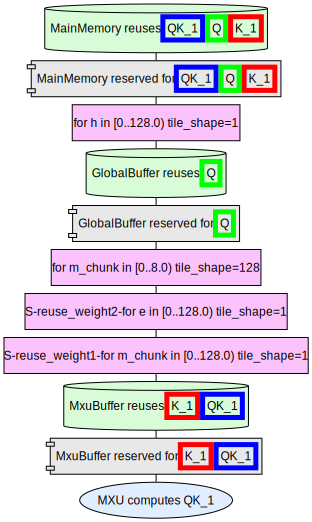

In [16]:
qk_results

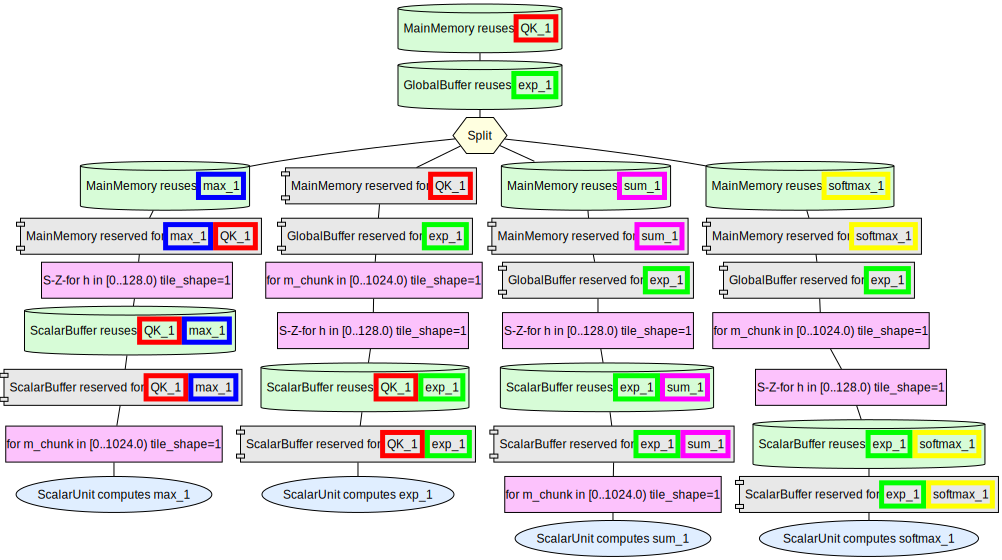

In [17]:
sm_results

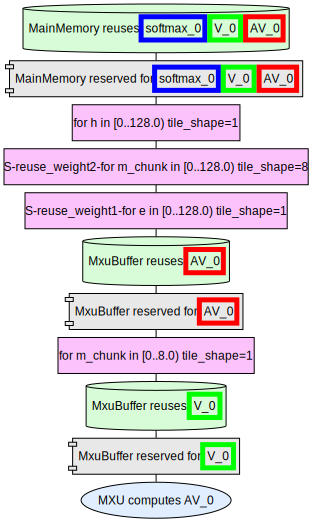

In [18]:
av_results

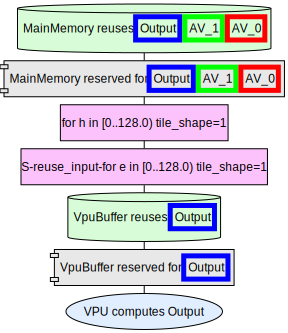

In [19]:
acc_results

## P1

In [20]:
# Gathered Results
print("QK Total Cycles: ", get_cycles(qk_results))
print("QK Total Energy: ", get_energy(qk_results))
print("SM Total Cycles: ", get_cycles(sm_results))
print("SM Total Energy: ", get_energy(sm_results))
print("AV Total Cycles: ", get_cycles(av_results))
print("AV Total Energy: ", get_energy(av_results))
print("ACC Total Cycles: ", get_cycles(acc_results))
print("ACC Total Energy: ", get_energy(acc_results))

# Total Pipeline Results
print("Total Pipeline Cycles: ", 8*(get_cycles(qk_results)+get_cycles(sm_results)+get_cycles(av_results)+get_cycles(acc_results)))
print("Total Pipeline Energy: ", 8*(get_energy(qk_results)+get_energy(sm_results)+get_energy(av_results)+get_energy(acc_results)))

QK Total Cycles:  2.756461253738962e-05
QK Total Energy:  0.0011010254899878709
SM Total Cycles:  3.900952378899092e-06
SM Total Energy:  3.372192122578443e-05
AV Total Cycles:  2.756461253738962e-05
AV Total Energy:  0.0010987448393956648
ACC Total Cycles:  1.2190476184059662e-07
ACC Total Energy:  2.8405923653402333e-06
Total Pipeline Cycles:  0.00047321665772415145
Total Pipeline Energy:  0.017890662743797282


## P2

In [21]:
# Total Pipeline Cycles
t0_cycles = get_cycles(qk_results)
t1_cycles = max(get_cycles(qk_results), get_cycles(sm_results))
t2_cycles = max(get_cycles(av_results), get_cycles(sm_results))
t3_cycles = max(get_cycles(av_results), get_cycles(acc_results))
t4_cycles = max(get_cycles(qk_results), get_cycles(acc_results))
t5_cycles = max(get_cycles(qk_results), get_cycles(sm_results))
t6_cycles = max(get_cycles(av_results), get_cycles(sm_results))
t7_cycles = max(get_cycles(av_results), get_cycles(acc_results))
t8_cycles = get_cycles(acc_results)

print("Total Pipeline Cycles: ", t0_cycles+t1_cycles+t2_cycles+t3_cycles+t4_cycles+t5_cycles+t6_cycles+t7_cycles+t8_cycles)

Total Pipeline Cycles:  0.00022063880506095757
